# Model – SVM – Member 4


# Support Vector Machine (SVM) — Member 4

## Objectives

This notebook:

- Builds an SVM classifier without the leakage feature `duration`.
- Uses the same chronological train-test split as the other models.
- Uses stratified 5-fold cross-validation on the training set.
- Evaluates SVM using PR-AUC, ROC-AUC, recall, precision and F1-score.
- Compares SVM performance with and without feature selection.
- Uses scaling because SVM is sensitive to feature magnitudes.
- Evaluates the final selected SVM once on the untouched chronological test set.

### Member 4 Optimisation Topic
**Validation setup (Stratified 5-Fold Cross-Validation) and a with/without feature selection experiment.**

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

# Make src importable
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    CV_FOLDS,
    RANDOM_STATE,
    ROOT
)

print("Project root:", ROOT)
print("Random state:", RANDOM_STATE)
print("CV folds:", CV_FOLDS)
print("SVM notebook setup completed successfully!")

Project root: C:\Users\Yasindu\OneDrive\Desktop\projects\bank-telemarketing-predictor
Random state: 42
CV folds: 5
SVM notebook setup completed successfully!


## 1. Data and Chronological Train-Test Split

The cleaned Bank Marketing dataset is loaded using the shared SVM helper functions.

- Exact duplicate rows are removed before preprocessing.
- `duration` is excluded because it is only known after the marketing call and would cause data leakage.
- The first 80% of observations are used for training.
- The latest 20% are kept as the untouched chronological test set.
- The test set will not be used during cross-validation or feature-selection decisions.

In [2]:
from src.svm_model import (
    load_data,
    chronological_split,
    build_svm_pipeline
)

# Load cleaned data
X, y = load_data()

# Same chronological 80/20 split used by the other models
X_train, X_test, y_train, y_test = chronological_split(
    X,
    y,
    test_fraction=0.20
)

print("Rows after removing duplicates:", len(X))
print("Number of predictor features:", X.shape[1])

print("\nTraining set:")
print("Rows:", len(X_train))
print("Yes-rate:", f"{y_train.mean():.2%}")

print("\nTest set:")
print("Rows:", len(X_test))
print("Yes-rate:", f"{y_test.mean():.2%}")

print("\nLeakage check:")
print("duration present in X:", "duration" in X.columns)

Rows after removing duplicates: 41176
Number of predictor features: 19

Training set:
Rows: 32940
Yes-rate: 6.38%

Test set:
Rows: 8236
Yes-rate: 30.83%

Leakage check:
duration present in X: False


## 2. Baseline SVM with Stratified 5-Fold Cross-Validation

A baseline Support Vector Machine (SVM) with an RBF kernel is evaluated using
stratified 5-fold cross-validation on the training data only.

SVM is sensitive to feature scales, so numerical predictors are standardised
inside the modelling pipeline. Categorical predictors are one-hot encoded.

`class_weight="balanced"` is used because the training target is strongly
imbalanced.

PR-AUC is used as the primary evaluation metric. ROC-AUC, recall, precision,
and F1-score are also reported.

The chronological test set remains untouched during cross-validation.

In [3]:
# Stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Metrics used across the project
scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

# Baseline SVM
baseline_svm = build_svm_pipeline(
    C=1.0,
    gamma="scale",
    kernel="rbf",
    class_weight="balanced"
)

print("Running baseline SVM with Stratified 5-Fold CV...")
print("This may take a few minutes.")

baseline_cv = cross_validate(
    baseline_svm,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)

baseline_results = pd.DataFrame({
    "Metric": [
        "PR-AUC",
        "ROC-AUC",
        "Recall",
        "Precision",
        "F1"
    ],
    "Mean": [
        baseline_cv["test_pr_auc"].mean(),
        baseline_cv["test_roc_auc"].mean(),
        baseline_cv["test_recall"].mean(),
        baseline_cv["test_precision"].mean(),
        baseline_cv["test_f1"].mean()
    ],
    "Std": [
        baseline_cv["test_pr_auc"].std(),
        baseline_cv["test_roc_auc"].std(),
        baseline_cv["test_recall"].std(),
        baseline_cv["test_precision"].std(),
        baseline_cv["test_f1"].std()
    ]
})

print("\nBaseline SVM — Stratified 5-Fold CV Results")
display(
    baseline_results.style.format({
        "Mean": "{:.4f}",
        "Std": "{:.4f}"
    })
)

Running baseline SVM with Stratified 5-Fold CV...
This may take a few minutes.

Baseline SVM — Stratified 5-Fold CV Results


,Metric,Mean,Std
0,PR-AUC,0.1563,0.0088
1,ROC-AUC,0.6581,0.0082
2,Recall,0.4876,0.0255
3,Precision,0.1220,0.0049
4,F1,0.1951,0.0078


### Baseline Result — Without Feature Selection

The baseline SVM uses all 19 predictor variables after removing the leakage
feature `duration`.

Using stratified 5-fold cross-validation, the baseline SVM achieved:

- **PR-AUC:** 0.1563 ± 0.0088
- **ROC-AUC:** 0.6581 ± 0.0082
- **Recall:** 0.4876 ± 0.0255
- **Precision:** 0.1220 ± 0.0049
- **F1-score:** 0.1951 ± 0.0078

PR-AUC is treated as the primary metric because the target class is strongly
imbalanced.

This result is used as the **without feature selection** baseline for the
Member 4 optimisation experiment.

## 3. With vs Without Feature Selection Experiment

The baseline SVM uses all 19 predictors.

PE1 identified strong multicollinearity among `emp.var.rate`, `euribor3m`,
and `nr.employed`. The campaign EDA also identified `day_of_week` as a very
weak predictor.

For the feature-selection experiment, the following variables are removed:

- `emp.var.rate`
- `nr.employed`
- `day_of_week`

`euribor3m` is retained as a representative of the highly correlated
macroeconomic group.

The reduced SVM is evaluated using the **same stratified 5-fold
cross-validation folds** as the baseline. This provides a fair comparison
between the models with and without feature selection.

In [4]:
# Feature-selection experiment
# Remove redundant/weak features identified during PE1

FEATURES_TO_REMOVE = [
    "emp.var.rate",
    "nr.employed",
    "day_of_week"
]

X_train_selected = X_train.drop(
    columns=FEATURES_TO_REMOVE,
    errors="ignore"
)

X_test_selected = X_test.drop(
    columns=FEATURES_TO_REMOVE,
    errors="ignore"
)

print("Original number of features:", X_train.shape[1])
print("Selected number of features:", X_train_selected.shape[1])

print("\nRemoved features:")
for feature in FEATURES_TO_REMOVE:
    print("-", feature)

print("\nRemaining features:")
print(X_train_selected.columns.tolist())

Original number of features: 19
Selected number of features: 16

Removed features:
- emp.var.rate
- nr.employed
- day_of_week

Remaining features:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']


### SVM With Feature Selection — Stratified 5-Fold CV

The reduced feature set is now evaluated using the same SVM configuration and
the same stratified 5-fold cross-validation setup as the baseline.

Keeping the model and validation folds unchanged ensures that the effect of
feature selection can be compared fairly against the 19-feature baseline.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

# Detect feature types AFTER feature selection
selected_categorical_features = (
    X_train_selected
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

selected_numerical_features = (
    X_train_selected
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

print("Categorical features:", len(selected_categorical_features))
print("Numerical features:", len(selected_numerical_features))

# Preprocessing for the selected 16 features
selected_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            selected_numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            selected_categorical_features
        )
    ]
)

# Same SVM settings as baseline
selected_classifier = SVC(
    C=1.0,
    gamma="scale",
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE
)

selected_svm = Pipeline(
    steps=[
        ("preprocessor", selected_preprocessor),
        ("classifier", selected_classifier)
    ]
)

print("\nRunning SVM WITH feature selection using Stratified 5-Fold CV...")
print("Features used:", X_train_selected.shape[1])
print("This may take a while.")

selected_cv = cross_validate(
    selected_svm,
    X_train_selected,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)

selected_results = pd.DataFrame({
    "Metric": ["PR-AUC", "ROC-AUC", "Recall", "Precision", "F1"],
    "Mean": [
        selected_cv["test_pr_auc"].mean(),
        selected_cv["test_roc_auc"].mean(),
        selected_cv["test_recall"].mean(),
        selected_cv["test_precision"].mean(),
        selected_cv["test_f1"].mean()
    ],
    "Std": [
        selected_cv["test_pr_auc"].std(),
        selected_cv["test_roc_auc"].std(),
        selected_cv["test_recall"].std(),
        selected_cv["test_precision"].std(),
        selected_cv["test_f1"].std()
    ]
})

print("\nSVM WITH Feature Selection — 5-Fold CV Results")

display(
    selected_results.style.format({
        "Mean": "{:.4f}",
        "Std": "{:.4f}"
    })
)

Categorical features: 9
Numerical features: 7

Running SVM WITH feature selection using Stratified 5-Fold CV...
Features used: 16
This may take a while.

SVM WITH Feature Selection — 5-Fold CV Results


,Metric,Mean,Std
0,PR-AUC,0.1429,0.0120
1,ROC-AUC,0.6553,0.0074
2,Recall,0.4852,0.0249
3,Precision,0.1194,0.0029
4,F1,0.1915,0.0042


## 4. Feature Selection Comparison

The two SVM configurations are now compared using the same stratified
5-fold cross-validation procedure.

The purpose of this experiment is to determine whether removing redundant
and weak predictors improves SVM performance.

In [7]:
comparison = pd.DataFrame({
    "Configuration": [
        "Without Feature Selection",
        "With Feature Selection"
    ],
    "Features": [
        X_train.shape[1],
        X_train_selected.shape[1]
    ],
    "PR-AUC": [
        baseline_cv["test_pr_auc"].mean(),
        selected_cv["test_pr_auc"].mean()
    ],
    "ROC-AUC": [
        baseline_cv["test_roc_auc"].mean(),
        selected_cv["test_roc_auc"].mean()
    ],
    "Recall": [
        baseline_cv["test_recall"].mean(),
        selected_cv["test_recall"].mean()
    ],
    "Precision": [
        baseline_cv["test_precision"].mean(),
        selected_cv["test_precision"].mean()
    ],
    "F1": [
        baseline_cv["test_f1"].mean(),
        selected_cv["test_f1"].mean()
    ]
})

display(
    comparison.style.format({
        "PR-AUC": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Configuration,Features,PR-AUC,ROC-AUC,Recall,Precision,F1
0,Without Feature Selection,19,0.1563,0.6581,0.4876,0.1220,0.1951
1,With Feature Selection,16,0.1429,0.6553,0.4852,0.1194,0.1915


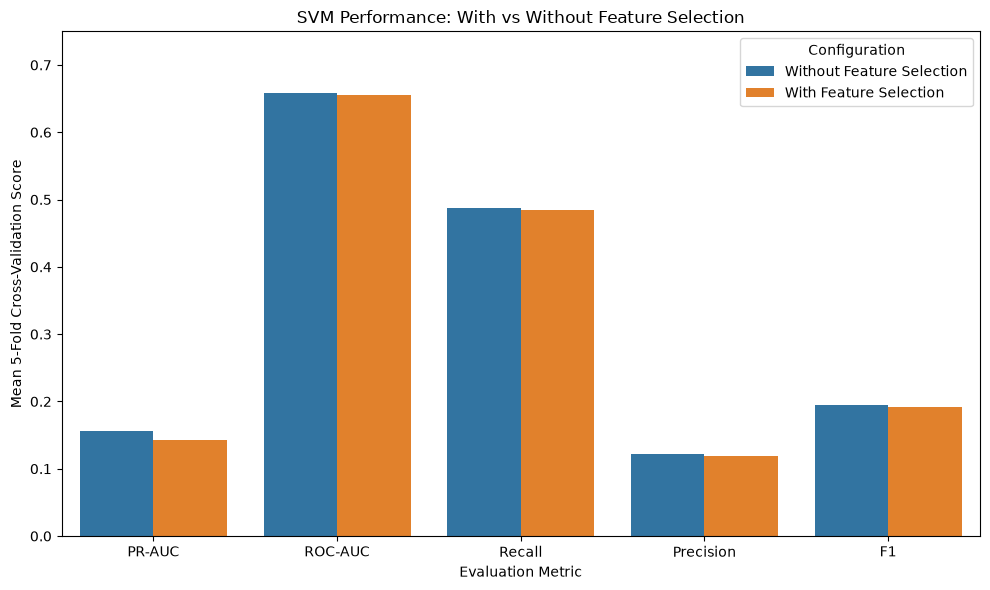

Figure saved to: C:\Users\Yasindu\OneDrive\Desktop\projects\bank-telemarketing-predictor\results\figures\svm_feature_selection_comparison.png


In [8]:
plot_data = comparison.melt(
    id_vars=["Configuration", "Features"],
    value_vars=[
        "PR-AUC",
        "ROC-AUC",
        "Recall",
        "Precision",
        "F1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Configuration"
)

plt.title("SVM Performance: With vs Without Feature Selection")
plt.xlabel("Evaluation Metric")
plt.ylabel("Mean 5-Fold Cross-Validation Score")
plt.ylim(0, 0.75)
plt.legend(title="Configuration")
plt.tight_layout()

FIGURES_DIR = ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = FIGURES_DIR / "svm_feature_selection_comparison.png"

plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", comparison_path)

### Feature Selection Result

The SVM without feature selection achieved a mean PR-AUC of **0.1563**,
while the reduced 16-feature model achieved **0.1429**.

Removing `emp.var.rate`, `nr.employed`, and `day_of_week` therefore did not
improve predictive performance. PR-AUC decreased by approximately 0.0134.

The other evaluation metrics also showed no improvement:

- ROC-AUC decreased from 0.6581 to 0.6553.
- Recall decreased slightly from 0.4876 to 0.4852.
- Precision decreased from 0.1220 to 0.1194.
- F1-score decreased from 0.1951 to 0.1915.

### Decision

The **SVM without feature selection** is retained for the final evaluation.

Although PE1 identified multicollinearity among several macroeconomic
variables and a weak relationship for `day_of_week`, removing these predictors
did not improve SVM performance under stratified 5-fold cross-validation.

This demonstrates why feature-selection decisions should be validated
experimentally rather than being based only on exploratory correlations.

## 5. Final SVM Evaluation on the Untouched Chronological Test Set

The feature-selection experiment showed that removing the selected predictors
reduced mean cross-validation PR-AUC. Therefore, the SVM using all 19
predictors is retained as the final Member 4 model.

The final SVM is now trained on the complete chronological training set and
evaluated once on the untouched chronological test set.

The test set was not used for feature-selection decisions or cross-validation.

In [9]:
# Build the selected final SVM: all 19 predictors
final_svm = build_svm_pipeline(
    C=1.0,
    gamma="scale",
    kernel="rbf",
    class_weight="balanced"
)

print("Training final SVM on the complete training set...")

final_svm.fit(X_train, y_train)

print("Training completed.")

# Probability estimates for final test evaluation
test_probabilities = final_svm.predict_proba(X_test)[:, 1]

# Default classification threshold
test_predictions = (test_probabilities >= 0.50).astype(int)

final_test_metrics = {
    "PR-AUC": average_precision_score(
        y_test,
        test_probabilities
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        test_probabilities
    ),
    "Recall": recall_score(
        y_test,
        test_predictions
    ),
    "Precision": precision_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        test_predictions,
        zero_division=0
    )
}

final_test_table = pd.DataFrame({
    "Metric": final_test_metrics.keys(),
    "Test Score": final_test_metrics.values()
})

print("\nFinal SVM — Chronological Test Results")

display(
    final_test_table.style.format({
        "Test Score": "{:.4f}"
    })
)

Training final SVM on the complete training set...
Training completed.

Final SVM — Chronological Test Results


,Metric,Test Score
0,PR-AUC,0.2840
1,ROC-AUC,0.5019
2,Recall,0.0000
3,Precision,0.0000
4,F1,0.0000


## 6. Confusion Matrix

The confusion matrix is used to inspect the final SVM's classification
behaviour on the chronological test set at the default 0.50 threshold.

The chronological test period contains a substantial distribution shift
relative to the training period, so threshold-dependent metrics must be
interpreted together with the ranking metrics.

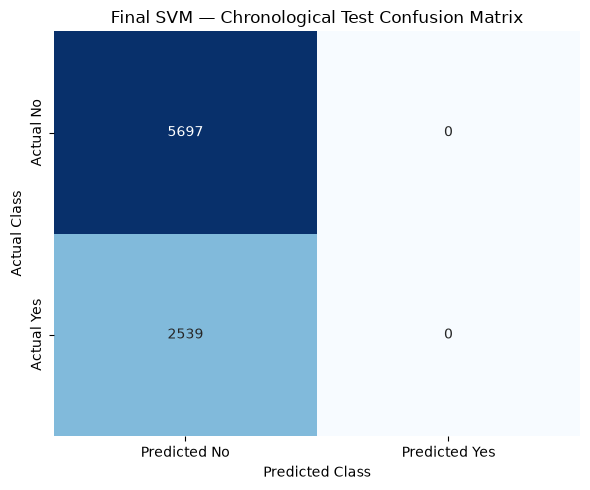

True Negatives: 5697
False Positives: 0
False Negatives: 2539
True Positives: 0
Figure saved to: C:\Users\Yasindu\OneDrive\Desktop\projects\bank-telemarketing-predictor\results\figures\svm_test_confusion_matrix.png


In [10]:
# Confusion matrix
cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted No", "Predicted Yes"],
    yticklabels=["Actual No", "Actual Yes"]
)

plt.title("Final SVM — Chronological Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

cm_path = FIGURES_DIR / "svm_test_confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
print("Figure saved to:", cm_path)

## 7. Precision–Recall Curve

At the default 0.50 classification threshold, the final SVM predicted every
test observation as the negative class. Therefore, threshold-dependent
metrics such as recall, precision, and F1 are zero.

The Precision–Recall curve evaluates the model across all possible decision
thresholds rather than relying only on the default 0.50 threshold.

This is especially important because the target is imbalanced and the
chronological test period has a substantially different positive-class rate
from the training period.

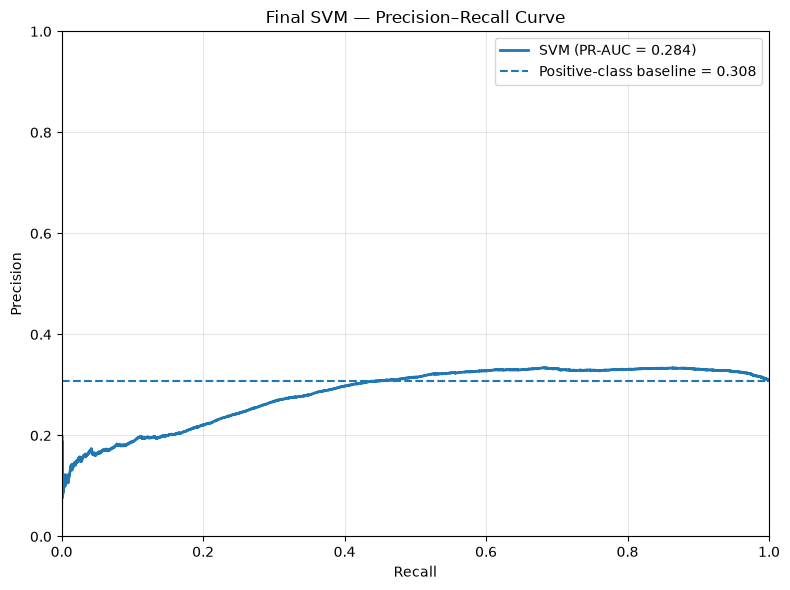

Test PR-AUC: 0.284
Positive-class baseline: 0.3083
Figure saved to: C:\Users\Yasindu\OneDrive\Desktop\projects\bank-telemarketing-predictor\results\figures\svm_test_precision_recall_curve.png


In [11]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    test_probabilities
)

test_pr_auc = final_test_metrics["PR-AUC"]
positive_baseline = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    linewidth=2,
    label=f"SVM (PR-AUC = {test_pr_auc:.3f})"
)

plt.axhline(
    y=positive_baseline,
    linestyle="--",
    label=f"Positive-class baseline = {positive_baseline:.3f}"
)

plt.title("Final SVM — Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

pr_curve_path = FIGURES_DIR / "svm_test_precision_recall_curve.png"

plt.savefig(
    pr_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Test PR-AUC:", round(test_pr_auc, 4))
print("Positive-class baseline:", round(positive_baseline, 4))
print("Figure saved to:", pr_curve_path)

## 8. Save Final SVM Model

The final SVM pipeline using all 19 predictors is saved so that the same
preprocessing and classification steps can be reused for later model
comparison or deployment.

In [12]:
MODELS_DIR = ROOT / "models" / "experiments"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

svm_model_path = MODELS_DIR / "svm_final.joblib"

joblib.dump(
    final_svm,
    svm_model_path
)

print("Final SVM model saved successfully.")
print("Model path:", svm_model_path)

Final SVM model saved successfully.
Model path: C:\Users\Yasindu\OneDrive\Desktop\projects\bank-telemarketing-predictor\models\experiments\svm_final.joblib


## 9. Final Findings and Conclusion

### Cross-Validation Results

The baseline SVM using all 19 predictors achieved a mean stratified 5-fold
cross-validation PR-AUC of **0.1563 ± 0.0088**.

The feature-selected SVM, using 16 predictors after removing
`emp.var.rate`, `nr.employed`, and `day_of_week`, achieved a lower mean
PR-AUC of **0.1429 ± 0.0120**.

The feature-selected model also showed slightly lower ROC-AUC, recall,
precision, and F1-score. Therefore, feature selection did not improve SVM
performance in this experiment.

### Feature-Selection Decision

The SVM **without feature selection** was retained as the final Member 4
configuration.

This experiment demonstrates that exploratory evidence of multicollinearity
or weak individual association does not necessarily mean that removing those
features will improve predictive performance. Feature-selection decisions
should therefore be validated using cross-validation.

### Chronological Test Performance

The final 19-feature SVM was evaluated once on the untouched chronological
test set and achieved:

- **PR-AUC:** 0.2840
- **ROC-AUC:** 0.5019
- **Recall:** 0.0000
- **Precision:** 0.0000
- **F1-score:** 0.0000

At the default 0.50 threshold, the model predicted all test observations as
the negative class:

- True Negatives: 5,697
- False Positives: 0
- False Negatives: 2,539
- True Positives: 0

The chronological training and test periods have substantially different
target distributions: the training positive rate is **6.38%**, whereas the
test positive rate is **30.83%**. This indicates a substantial temporal
distribution shift.

The test PR-AUC of **0.2840** is also below the chronological test
positive-class baseline of **0.3083**, while ROC-AUC is approximately 0.50.
Therefore, although the SVM showed some discrimination under stratified
cross-validation, it did not generalise effectively to the later
chronological test period.

### Member 4 PE2 Conclusion

The required **Stratified 5-Fold Cross-Validation and With/Without Feature
Selection experiment** was completed.

Feature selection reduced rather than improved cross-validation performance,
so the full 19-feature SVM was retained. However, the final chronological
evaluation revealed poor generalisation under temporal distribution shift.

Therefore, the SVM results should be used as an important comparison in the
final model-selection stage rather than interpreting cross-validation
performance alone as evidence of deployment performance.